In [1]:
# Cell 1 — Mount Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os

# Verify your split data is there
SPLIT_DIR = "/content/drive/MyDrive/deepfake/dataset/split"

for split in ["train", "val"]:
    for cls in ["real", "fake"]:
        path  = f"{SPLIT_DIR}/{split}/{cls}"
        count = len(os.listdir(path)) if os.path.exists(path) else "MISSING"
        print(f"  {split}/{cls}: {count}")


Mounted at /content/drive
  train/real: 4400
  train/fake: 4400
  val/real: 1100
  val/fake: 1100


In [2]:
# Cell 2 — Install
!pip install -q timm albumentations torchmetrics

import torch
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
print(f"GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NONE — switch to T4 GPU'}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 25.0 MB/s eta 0:00:00
PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4


In [3]:
# Cell 3 — Transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2

MEAN = (0.485, 0.456, 0.406)
STD  = (0.229, 0.224, 0.225)

def get_train_transform():
    return A.Compose([
        A.Resize(224, 224),
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=15, p=0.5),
        A.RandomBrightnessContrast(p=0.5),
        A.GaussNoise(p=0.2),
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2(),
    ])

def get_val_transform():
    return A.Compose([
        A.Resize(224, 224),
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2(),
    ])

print("Transforms ready")

Transforms ready


In [4]:
# Cell 4 — Dataset
import os
import cv2
import torch
from torch.utils.data import Dataset
from pathlib import Path

class DeepfakeDataset(Dataset):

    def __init__(self, data_dir: str, split: str = None, transform=None):
        self.transform   = transform
        self.image_paths = []
        self.labels      = []

        root     = Path(data_dir) / split if split else Path(data_dir)
        real_dir = root / "real"
        fake_dir = root / "fake"

        valid_ext = {".jpg", ".jpeg", ".png", ".webp"}

        for img_name in sorted(os.listdir(real_dir)):
            if Path(img_name).suffix.lower() in valid_ext:
                self.image_paths.append(str(real_dir / img_name))
                self.labels.append(0)

        for img_name in sorted(os.listdir(fake_dir)):
            if Path(img_name).suffix.lower() in valid_ext:
                self.image_paths.append(str(fake_dir / img_name))
                self.labels.append(1)

        print(f"[DeepfakeDataset] split={split or 'flat'} | "
              f"real={self.labels.count(0)} | "
              f"fake={self.labels.count(1)} | "
              f"total={len(self.labels)}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path  = self.image_paths[idx]
        label = self.labels[idx]
        image = cv2.imread(path)
        if image is None:
            raise RuntimeError(f"Could not read: {path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transform:
            image = self.transform(image=image)["image"]
        return image, torch.tensor(label, dtype=torch.long)

    def class_counts(self):
        return {
            "real": self.labels.count(0),
            "fake": self.labels.count(1),
        }

print("Dataset class ready")

Dataset class ready


In [5]:
# Cell 5 — EfficientNet-B4 Model
import timm
import torch.nn as nn

class DeepfakeDetector(nn.Module):

    def __init__(self, pretrained=True, dropout=0.3):
        super().__init__()
        self.backbone = timm.create_model(
            "efficientnet_b4",
            pretrained=pretrained,
            num_classes=0,
            global_pool="avg",
        )
        feat_dim = self.backbone.num_features  # 1792

        self.head = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(feat_dim, 256),
            nn.ReLU(),
            nn.Dropout(p=dropout / 2),
            nn.Linear(256, 2),
        )

    def forward(self, x):
        return self.head(self.backbone(x))

# Quick check
model  = DeepfakeDetector(pretrained=False)
dummy  = torch.randn(2, 3, 224, 224)
output = model(dummy)
print(f"Output shape : {output.shape}")   # expect (2, 2)
print(f"Params       : {sum(p.numel() for p in model.parameters()):,}")
print("Model ready")

Output shape : torch.Size([2, 2])
Params       : 18,008,138
Model ready


In [6]:
# Cell 6 — DataLoaders
from torch.utils.data import DataLoader

SPLIT_DIR  = "/content/drive/MyDrive/deepfake/dataset/split"
BATCH_SIZE = 32   # 32 is safe on T4, faster than 16

train_ds = DeepfakeDataset(SPLIT_DIR, split="train", transform=get_train_transform())
val_ds   = DeepfakeDataset(SPLIT_DIR, split="val",   transform=get_val_transform())

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

# Sanity check
images, labels = next(iter(train_loader))
print(f"Train : {len(train_ds)} | Val : {len(val_ds)}")
print(f"Batch shape : {images.shape}")
print(f"Pixel range : [{images.min():.2f}, {images.max():.2f}]")
print("DataLoaders ready")

[DeepfakeDataset] split=train | real=4400 | fake=4400 | total=8800
[DeepfakeDataset] split=val | real=1100 | fake=1100 | total=2200
Train : 8800 | Val : 2200
Batch shape : torch.Size([32, 3, 224, 224])
Pixel range : [-2.12, 2.64]
DataLoaders ready


In [7]:
# Cell 7 — Training loop
import time
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

# ── Config ──────────────────────────────────────────────────────────────
EPOCHS    = 10
LR        = 3e-4
PATIENCE  = 3
CKPT_PATH = "/content/drive/MyDrive/deepfake/checkpoints/best_model.pth"
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs("/content/drive/MyDrive/deepfake/checkpoints", exist_ok=True)

# ── Setup ───────────────────────────────────────────────────────────────
model     = DeepfakeDetector(pretrained=True).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

print(f"Device : {DEVICE}")
print(f"Model  : EfficientNet-B4")
print(f"Epochs : {EPOCHS}")
print("Starting training...\n")

best_val_acc = 0.0
patience_cnt = 0
history      = []

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    # ── Train ──────────────────────────────────────────────────────────
    model.train()
    train_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
        correct    += outputs.argmax(1).eq(labels).sum().item()
        total      += labels.size(0)

    train_loss /= len(train_loader)
    train_acc   = correct / total

    # ── Validate ───────────────────────────────────────────────────────
    model.eval()
    val_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs  = model(images)
            val_loss += criterion(outputs, labels).item()
            correct  += outputs.argmax(1).eq(labels).sum().item()
            total    += labels.size(0)

    val_loss /= len(val_loader)
    val_acc   = correct / total
    elapsed   = time.time() - t0

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.4f} | "
          f"{elapsed:.1f}s")

    history.append({
        "epoch": epoch, "train_loss": round(train_loss, 4),
        "train_acc": round(train_acc, 4), "val_loss": round(val_loss, 4),
        "val_acc": round(val_acc, 4),
    })

    # ── Checkpoint ─────────────────────────────────────────────────────
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_cnt = 0
        torch.save({
            "epoch":       epoch,
            "model_state": model.state_dict(),
            "val_acc":     val_acc,
            "val_loss":    val_loss,
        }, CKPT_PATH)
        print(f"  ✓ Saved best model  (val_acc={val_acc:.4f})")
    else:
        patience_cnt += 1
        print(f"  No improvement ({patience_cnt}/{PATIENCE})")
        if patience_cnt >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}")
            break

    scheduler.step()

print(f"\nBest val accuracy : {best_val_acc:.4f}")
print(f"Checkpoint saved  : {CKPT_PATH}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Device : cuda
Model  : EfficientNet-B4
Epochs : 10
Starting training...

Epoch 01/10 | train loss 0.4072 acc 0.7956 | val loss 0.1905 acc 0.9282 | 836.1s
  ✓ Saved best model  (val_acc=0.9282)
Epoch 02/10 | train loss 0.2241 acc 0.8970 | val loss 0.1518 acc 0.9409 | 153.8s
  ✓ Saved best model  (val_acc=0.9409)
Epoch 03/10 | train loss 0.1615 acc 0.9285 | val loss 0.1314 acc 0.9473 | 155.4s
  ✓ Saved best model  (val_acc=0.9473)
Epoch 04/10 | train loss 0.1294 acc 0.9434 | val loss 0.1698 acc 0.9491 | 156.2s
  ✓ Saved best model  (val_acc=0.9491)
Epoch 05/10 | train loss 0.1180 acc 0.9483 | val loss 0.1326 acc 0.9595 | 156.7s
  ✓ Saved best model  (val_acc=0.9595)
Epoch 06/10 | train loss 0.0962 acc 0.9563 | val loss 0.1405 acc 0.9564 | 156.0s
  No improvement (1/3)
Epoch 07/10 | train loss 0.0830 acc 0.9637 | val loss 0.1509 acc 0.9614 | 154.9s
  ✓ Saved best model  (val_acc=0.9614)
Epoch 08/10 | train loss 0.0839 acc 0.9627 | val loss 0.1505 acc 0.9605 | 156.3s
  No improvement (1/3)

In [8]:
# Cell 9 — Eval packages
!pip install -q scikit-learn seaborn

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Eval packages ready")

Eval packages ready


In [9]:
# Cell 10 — Load checkpoint and run inference on val set
CKPT_PATH = "/content/drive/MyDrive/deepfake/checkpoints/best_model.pth"
OUT_DIR   = "/content/drive/MyDrive/deepfake/output"
os.makedirs(OUT_DIR, exist_ok=True)

# Load best checkpoint
model_eval = DeepfakeDetector(pretrained=False).to(DEVICE)
ckpt       = torch.load(CKPT_PATH, map_location=DEVICE)
model_eval.load_state_dict(ckpt["model_state"])
model_eval.eval()
print(f"Loaded — epoch {ckpt['epoch']} | val_acc {ckpt['val_acc']:.4f}")

# Run on entire val set
val_ds_eval = DeepfakeDataset(
    SPLIT_DIR, split="val", transform=get_val_transform()
)
eval_loader = DataLoader(
    val_ds_eval, batch_size=32, shuffle=False, num_workers=2
)

all_labels, all_preds, all_probs = [], [], []

with torch.no_grad():
    for images, labels in eval_loader:
        images  = images.to(DEVICE)
        logits  = model_eval(images)
        probs   = torch.softmax(logits, dim=1)[:, 1]
        preds   = logits.argmax(dim=1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)

print(f"Evaluated {len(all_labels)} images")
print(f"Correct   {(all_labels == all_preds).sum()} / {len(all_labels)}")

Loaded — epoch 7 | val_acc 0.9614
[DeepfakeDataset] split=val | real=1100 | fake=1100 | total=2200
Evaluated 2200 images
Correct   2115 / 2200


In [12]:
# Cell 11 — Classification report
CLASSES = ["real", "fake"]

print("Classification Report")
print("=" * 46)
print(classification_report(all_labels, all_preds, target_names=CLASSES))



Classification Report
              precision    recall  f1-score   support

        real       0.97      0.96      0.96      1100
        fake       0.96      0.97      0.96      1100

    accuracy                           0.96      2200
   macro avg       0.96      0.96      0.96      2200
weighted avg       0.96      0.96      0.96      2200



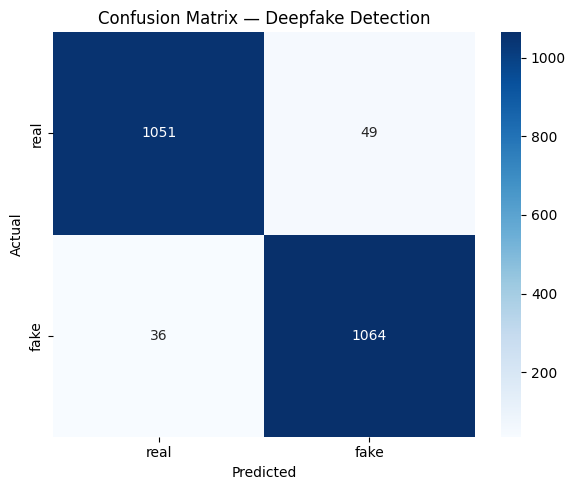

True  Negatives (real called real) : 1051
False Positives (real called fake) : 49
False Negatives (fake called real) : 36
True  Positives (fake called fake) : 1064


In [13]:
# Cell 12 — Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASSES, yticklabels=CLASSES, ax=ax
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Deepfake Detection")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/confusion_matrix.png", dpi=150)
plt.show()

# Print what the matrix means
tn, fp, fn, tp = cm.ravel()
print(f"True  Negatives (real called real) : {tn}")
print(f"False Positives (real called fake) : {fp}")
print(f"False Negatives (fake called real) : {fn}")
print(f"True  Positives (fake called fake) : {tp}")

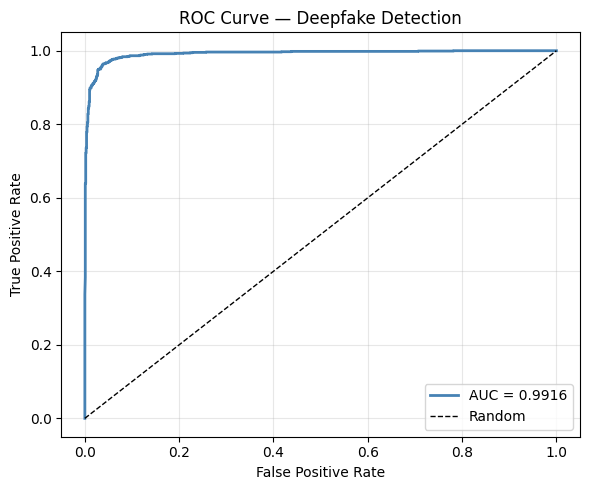

AUC Score : 0.9916
Plots saved to /content/drive/MyDrive/deepfake/output


In [14]:
# Cell 13 — ROC curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
auc         = roc_auc_score(all_labels, all_probs)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, lw=2, color="steelblue", label=f"AUC = {auc:.4f}")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Deepfake Detection")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/roc_curve.png", dpi=150)
plt.show()

print(f"AUC Score : {auc:.4f}")
print(f"Plots saved to {OUT_DIR}")

In [16]:
# Cell 14 — ONNX export (fixed)
!pip install -q onnxscript onnxruntime

import os
import onnxruntime as ort

ONNX_PATH = "/content/drive/MyDrive/deepfake/exports/deepfake_detector.onnx"
os.makedirs("/content/drive/MyDrive/deepfake/exports", exist_ok=True)

model_eval.eval()
dummy_input = torch.randn(1, 3, 224, 224, device=DEVICE)

torch.onnx.export(
    model_eval,
    dummy_input,
    ONNX_PATH,
    export_params=True,
    opset_version=17,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={
        "input":  {0: "batch_size"},
        "output": {0: "batch_size"},
    },
)
print(f"ONNX exported → {ONNX_PATH}")

# Verify it loads and runs
sess    = ort.InferenceSession(ONNX_PATH, providers=["CPUExecutionProvider"])
test_in = dummy_input.cpu().numpy()
result  = sess.run(None, {"input": test_in})

print(f"ONNX output shape : {result[0].shape}")   # expect (1, 2)
print(f"ONNX raw logits   : {result[0]}")
print("\nStage 3 COMPLETE — model evaluated and exported")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 16.4 MB/s eta 0:00:00


/tmp/ipykernel_658/113871711.py:13: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0322 08:13:26.777000 658 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0322 08:13:27.520000 658 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, align

[torch.onnx] Obtain model graph for `DeepfakeDetector([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DeepfakeDetector([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:65: adapt: Asserti

Applied 193 of general pattern rewrite rules.
ONNX exported → /content/drive/MyDrive/deepfake/exports/deepfake_detector.onnx
ONNX output shape : (1, 2)
ONNX raw logits   : [[ 0.33096573 -0.30095613]]

Stage 3 COMPLETE — model evaluated and exported


In [17]:
# Cell 15 — Grad-CAM core class
import cv2
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

class GradCAM:
    def __init__(self, model):
        self.model       = model
        self.gradients   = None
        self.activations = None

        # Hook into last conv block of EfficientNet-B4
        target_layer = model.backbone.blocks[-1]
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def compute(self, image_tensor, class_idx=None):
        self.model.eval()
        image_tensor = image_tensor.requires_grad_(True)

        logits = self.model(image_tensor)
        probs  = torch.softmax(logits, dim=1)

        pred_class = logits.argmax(dim=1).item()
        confidence = probs[0][pred_class].item() * 100

        if class_idx is None:
            class_idx = pred_class

        self.model.zero_grad()
        logits[0, class_idx].backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)
        cam     = F.relu(cam)
        cam     = F.interpolate(cam, size=(224, 224),
                                mode="bilinear", align_corners=False)

        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam, pred_class, confidence


def overlay_heatmap(image_np, heatmap, alpha=0.45):
    heatmap_uint8 = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_rgb   = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    heatmap_rgb   = cv2.resize(heatmap_rgb,
                               (image_np.shape[1], image_np.shape[0]))
    return cv2.addWeighted(image_np, 1 - alpha, heatmap_rgb, alpha, 0)


def load_image_for_gradcam(image_path):
    transform = get_val_transform()
    image_np  = cv2.imread(image_path)
    image_np  = cv2.cvtColor(image_np, cv2.COLOR_BGR2RGB)
    image_np  = cv2.resize(image_np, (224, 224))
    tensor    = transform(image=image_np)["image"].unsqueeze(0).to(DEVICE)
    return image_np, tensor


CLASSES = ["real", "fake"]
print("Grad-CAM class ready")

Grad-CAM class ready


In [18]:
# Cell 16 — Load best model into Grad-CAM
CKPT_PATH = "/content/drive/MyDrive/deepfake/checkpoints/best_model.pth"

gradcam_model = DeepfakeDetector(pretrained=False).to(DEVICE)
ckpt          = torch.load(CKPT_PATH, map_location=DEVICE)
gradcam_model.load_state_dict(ckpt["model_state"])
gradcam_model.eval()

gradcam = GradCAM(gradcam_model)
print(f"Grad-CAM ready — epoch {ckpt['epoch']} | val_acc {ckpt['val_acc']:.4f}")

Grad-CAM ready — epoch 7 | val_acc 0.9614


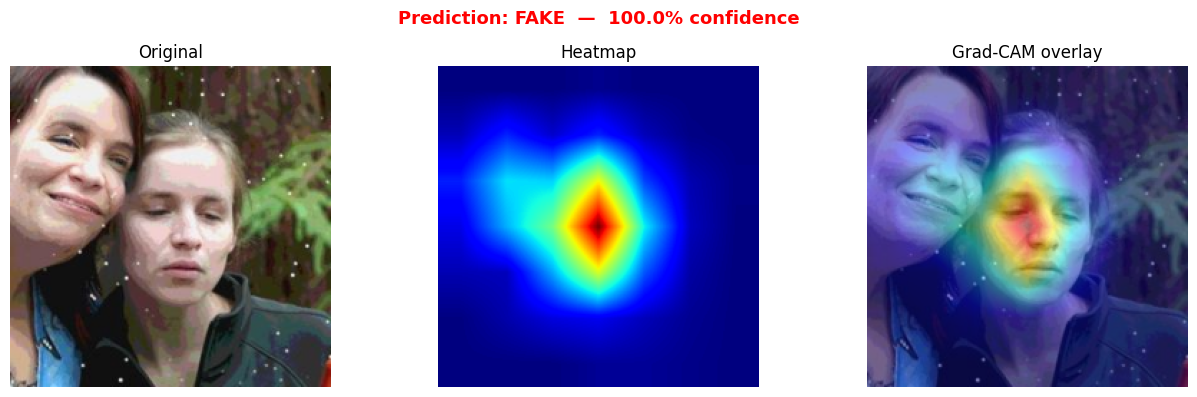

Saved → /content/drive/MyDrive/deepfake/output/gradcam/gradcam_single.png


In [19]:
# Cell 17 — Single image explanation
import glob, random

OUT_DIR = "/content/drive/MyDrive/deepfake/output/gradcam"
os.makedirs(OUT_DIR, exist_ok=True)

# Pick one fake image from val set
fake_samples = glob.glob(f"{SPLIT_DIR}/val/fake/*")
real_samples = glob.glob(f"{SPLIT_DIR}/val/real/*")

test_image = random.choice(fake_samples)   # change to real_samples to test real

image_np, image_tensor = load_image_for_gradcam(test_image)
heatmap, pred_class, confidence = gradcam.compute(image_tensor)
overlay = overlay_heatmap(image_np, heatmap)

label = CLASSES[pred_class]
color = "red" if pred_class == 1 else "green"

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle(
    f"Prediction: {label.upper()}  —  {confidence:.1f}% confidence",
    fontsize=13, color=color, fontweight="bold"
)
axes[0].imshow(image_np);             axes[0].set_title("Original");      axes[0].axis("off")
axes[1].imshow(heatmap, cmap="jet");  axes[1].set_title("Heatmap");       axes[1].axis("off")
axes[2].imshow(overlay);              axes[2].set_title("Grad-CAM overlay"); axes[2].axis("off")

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/gradcam_single.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {OUT_DIR}/gradcam_single.png")

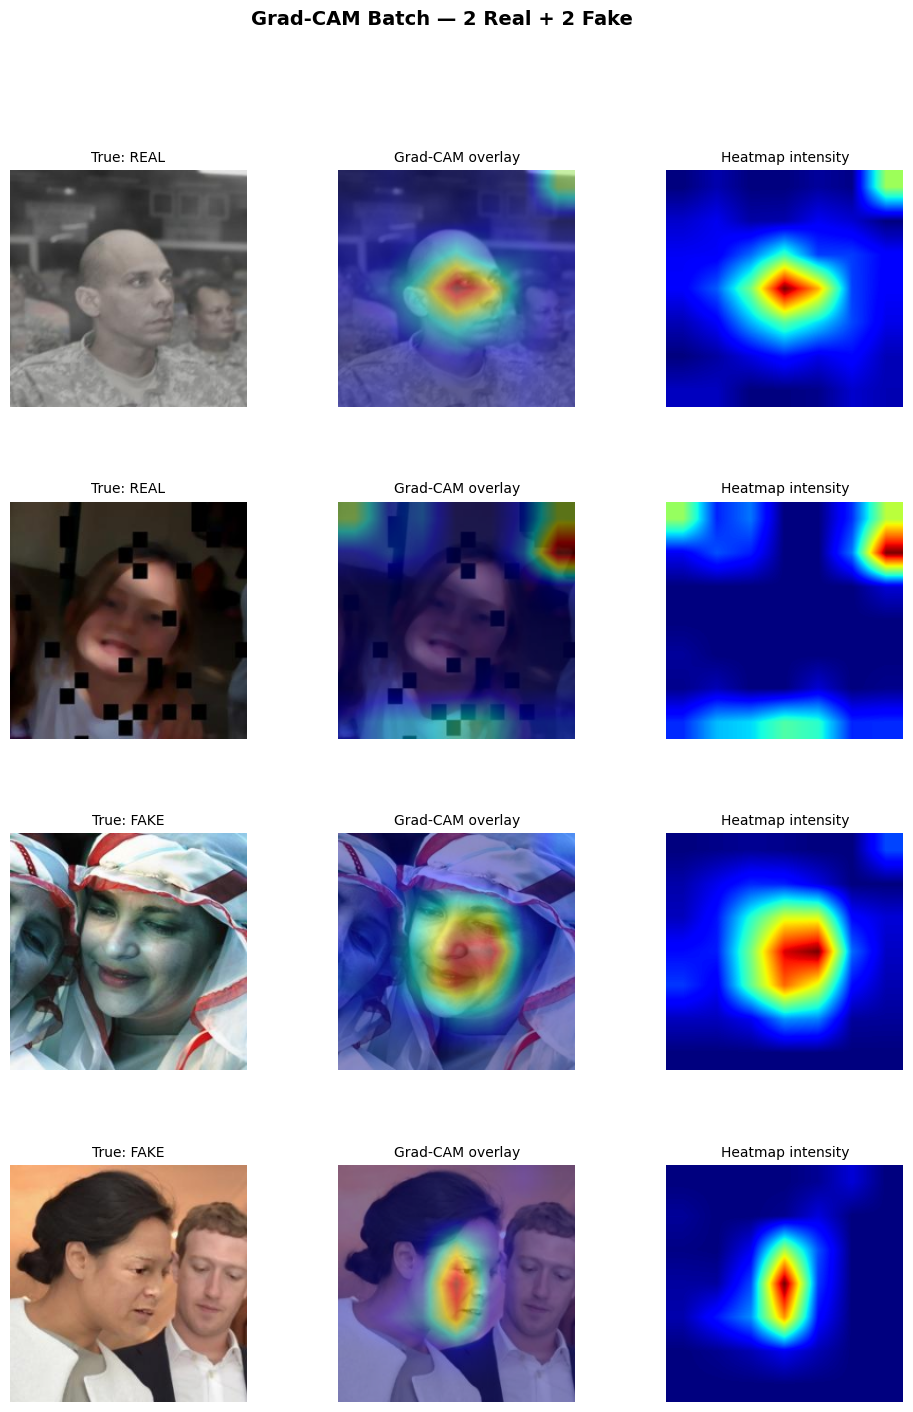

Saved → /content/drive/MyDrive/deepfake/output/gradcam/gradcam_batch.png

Grad-CAM complete — outputs saved to Drive


In [20]:
# Cell 18 — Batch Grad-CAM grid
samples = (
    random.sample(real_samples, 2) +
    random.sample(fake_samples, 2)
)
sample_types = ["real", "real", "fake", "fake"]

n   = len(samples)
fig = plt.figure(figsize=(12, 4 * n))
gs  = gridspec.GridSpec(n, 3, figure=fig, hspace=0.4)
fig.suptitle("Grad-CAM Batch — 2 Real + 2 Fake",
             fontsize=14, fontweight="bold")

for i, (img_path, true_label) in enumerate(zip(samples, sample_types)):
    image_np, image_tensor = load_image_for_gradcam(img_path)
    heatmap, pred_class, conf = gradcam.compute(image_tensor)
    overlay = overlay_heatmap(image_np, heatmap)

    pred  = CLASSES[pred_class]
    color = "red" if pred_class == 1 else "green"
    correct = "✓" if pred == true_label else "✗"

    ax0 = fig.add_subplot(gs[i, 0])
    ax1 = fig.add_subplot(gs[i, 1])
    ax2 = fig.add_subplot(gs[i, 2])

    ax0.imshow(image_np)
    ax0.set_title(f"True: {true_label.upper()}", fontsize=10)
    ax0.axis("off")

    ax1.imshow(overlay)
    ax1.set_title("Grad-CAM overlay", fontsize=10)
    ax1.axis("off")

    ax2.imshow(heatmap, cmap="jet")
    ax2.set_title("Heatmap intensity", fontsize=10)
    ax2.axis("off")

    ax0.set_ylabel(
        f"{correct} Pred: {pred.upper()}\n{conf:.1f}%",
        fontsize=10, color=color,
        rotation=0, labelpad=70, va="center"
    )

plt.savefig(f"{OUT_DIR}/gradcam_batch.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {OUT_DIR}/gradcam_batch.png")
print("\nGrad-CAM complete — outputs saved to Drive")